# Generating Points on the Flag Manifold

## Setup

In [1]:
import manifoldqmcpy
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Theoretical Moments

In [2]:
def theoretical_1_moments_real_orthogonal(lam):
    t = lam.size(-1)
    return lam.sum(-1)/t*torch.eye(t,device=DEVICE)
def theoretical_2_moments_real_orthogonal(lam):
    t = lam.size(-1)
    T1 = torch.sum(lam)**2
    T2 = torch.sum(lam**2)
    denom = t*(t-1)*(t+2)
    alpha = ((t+1)*T1-2*T2)/denom
    beta = (t*T2-T1)/denom
    eye_vec = torch.eye(t,device=DEVICE).flatten()
    M1 = eye_vec[...,:,None]*eye_vec[...,None,:]
    M2 = torch.eye(t**2,device=DEVICE)
    W = torch.zeros((t**2,t**2),device=DEVICE)
    for i in range(t):
        for j in range(t):
            W[i*t+j,j*t+i] = 1
    return alpha*M1+beta*(M2+W)
lam = torch.arange(1,5,device=DEVICE) 
x,w = manifoldqmcpy.genflag_x_eig_iid_equal_w(2**20,lam=lam)
E1hat = (w[...,:,None,None]*x).sum(-3)
xf = x.flatten(start_dim=-2)
E2hat = (w[...,:,None,None]*xf[...,:,None]*xf[...,None,:]).sum(-3)
print()
E1 = theoretical_1_moments_real_orthogonal(lam)
E2 = theoretical_2_moments_real_orthogonal(lam)
with np.printoptions(formatter={"float":lambda x: "%.1e"%x},linewidth=np.inf):
    print("E1")
    print(E1.cpu().numpy())
    print("E1hat")
    print(E1hat.cpu().numpy())
    print()
    print("E2")
    print(E2.cpu().numpy())
    print("E2hat")
    print(E2hat.cpu().numpy())
assert torch.allclose(E1,E1hat,atol=1e-2)
assert torch.allclose(E2,E2hat,atol=1e-2)


E1
[[2.5e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 2.5e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 2.5e+00 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.5e+00]]
E1hat
[[2.5e+00 3.4e-04 -5.7e-04 -2.9e-04]
 [3.4e-04 2.5e+00 -3.4e-04 6.1e-04]
 [-5.7e-04 -3.4e-04 2.5e+00 6.8e-04]
 [-2.9e-04 6.1e-04 6.8e-04 2.5e+00]]

E2
[[6.7e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6.1e+00]
 [0.0e+00 2.8e-01 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00]
 [0.0e+00 2.8e-01 0.0e+00 0.0e+00 2.8e-01 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]
 [6.1e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 6

## Kernel Mean Testing

In [3]:
x,wx = manifoldqmcpy.genflag_x_eig_iid_equal_w(2**3,lam=lam)
y,wy = manifoldqmcpy.genflag_x_eig_iid_equal_w(2**18,lam=lam)
print("x.shape = %s"%str(tuple(x.shape)))
print("wx.shape = %s"%str(tuple(wx.shape)))
print("y.shape = %s"%str(tuple(y.shape)))
print("wy.shape = %s"%str(tuple(wy.shape)))
tryx = torch.einsum("ijk,ljk->il",x,y)
print("tryx.shape = %s"%str(tuple(tryx.shape)))
int_tryx_dy = (tryx*wy).sum(-1)
assert torch.allclose(int_tryx_dy,lam.sum()**2/lam.size(-1),atol=1e-2)
print("int_tryx_dy.shape = %s"%str(tuple(int_tryx_dy.shape)))
print("int_tryx_dy = \n%s\t"%str(int_tryx_dy))
int_int_tryx_dy_dx = (int_tryx_dy*wx).sum(-1)
print("int_int_tryx_dy_dx = %.8f"%int_int_tryx_dy_dx)
assert torch.allclose(int_int_tryx_dy_dx,lam.sum()**2/lam.size(-1),atol=5e-3)

x.shape = (8, 4, 4)
wx.shape = (8,)
y.shape = (262144, 4, 4)
wy.shape = (262144,)
tryx.shape = (8, 262144)
int_tryx_dy.shape = (8,)
int_tryx_dy = 
tensor([25.0001, 24.9989, 25.0035, 25.0035, 25.0037, 24.9990, 25.0002, 25.0023])	
int_int_tryx_dy_dx = 25.00140812


## Optimized Points and Weights

In [4]:
def genf_opt1_x_w(n, lam, seed=None, verbose=False):
    t = lam.size(-1)
    theta0 = torch.cat([
        torch.ones((n,1),device=DEVICE)/n,
        agsutil.to_unitary_qr(torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE).reshape((n,t,t))).flatten(start_dim=-2),
        ],dim=-1)
    E1 = theoretical_1_moments_real_orthogonal(lam)
    def loss(theta):
        w = theta[...,0]
        u = theta[...,1:].reshape((*theta.shape[:-1],t,t))
        q = agsutil.to_unitary_qr(u)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xsum = torch.einsum("...i,...ijk->...jk",w,x)
        return xsum,x,w
    theta,x,w = agsutil.lm_opt(
        f = loss, 
        theta0 = theta0, 
        ytrue = E1,
        iters = 100,
        verbose = verbose,
    )
    return x,w
x,w = genf_opt1_x_w(n=128,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=7)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.2e+00   | 3.2e+00   | 3.2e+00   | 3.2e+00   | 3.2e+00   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.3        
    1          | 1.1e-03   | 1.1e-03   | 1.1e-03   | 1.1e-03   | 1.1e-03   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+0

In [5]:
def genf_opt1_x_equal_w(n, lam, seed=None, verbose=False):
    t = lam.size(-1)
    theta0 = agsutil.to_unitary_qr(torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE).reshape((n,t,t))).flatten(start_dim=-2)
    E1 = theoretical_1_moments_real_orthogonal(lam)
    w = torch.ones(n,device=DEVICE)/n
    def loss(theta):
        theta = theta.reshape((*theta.shape[:-1],t,t))
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xsum = torch.einsum("...i,...ijk->...jk",w,x)
        return xsum,x
    theta,x = agsutil.lm_opt(
        f = loss, 
        theta0 = theta0, 
        ytrue = E1,
        iters = 100,
        verbose = verbose,
    )
    return x,w
x,w = genf_opt1_x_equal_w(n=128,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=7)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.2e+00   | 3.2e+00   | 3.2e+00   | 3.2e+00   | 3.2e+00   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.0        
    1          | 9.5e-02   | 9.5e-02   | 9.5e-02   | 9.5e-02   | 9.5e-02   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+0

In [7]:
def genf_opt2_x_w(n, lam, seed=None, verbose=False):
    t = lam.size(-1)
    theta0 = torch.cat([
        torch.ones((n,1),device=DEVICE)/n,
        agsutil.to_unitary_qr(torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE).reshape((n,t,t))).flatten(start_dim=-2),
        ],dim=-1)
    E2 = theoretical_2_moments_real_orthogonal(lam)
    def loss(theta):
        w = theta[...,0]
        u = theta[...,1:].reshape((*theta.shape[:-1],t,t))
        q = agsutil.to_unitary_qr(u)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xf = x.flatten(start_dim=-2)
        xsum = torch.einsum("...ij,...ik,...i->...jk",xf,xf,w)
        return xsum,x,w
    theta,x,w = agsutil.lm_opt(
        f = loss, 
        theta0 = theta0, 
        ytrue = E2,
        iters = 100,
        verbose = verbose,
    )
    return x,w
x,w = genf_opt2_x_w(n=256,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=11)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.0e+02   | 3.0e+02   | 3.0e+02   | 3.0e+02   | 3.0e+02   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.2        
    1          | 9.7e+00   | 9.7e+00   | 9.7e+00   | 9.7e+00   | 9.7e+00   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 5.0e-07   | 5.0e-01   | 5.0e-01   | 5.0e-0

In [8]:
def genf_opt2_x_equal_w(n, lam, seed=None, verbose=False):
    t = lam.size(-1)
    theta0 = agsutil.to_unitary_qr(torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE).reshape((n,t,t))).flatten(start_dim=-2)
    E2 = theoretical_2_moments_real_orthogonal(lam)
    w = torch.ones(n,device=DEVICE)/n
    def loss(theta):
        theta = theta.reshape((*theta.shape[:-1],t,t))
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        xf = x.flatten(start_dim=-2)
        xsum = torch.einsum("...ij,...ik,...i->...jk",xf,xf,w)
        return xsum,x
    u,x = agsutil.lm_opt(
        f = loss, 
        theta0 = theta0, 
        ytrue = E2,
        iters = 100,
        verbose = verbose,
    )
    return x,w
x,w = genf_opt2_x_equal_w(n=256,lam=torch.arange(1,6,dtype=float,device=DEVICE),verbose=1,seed=11)

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.0e+02   | 3.0e+02   | 3.0e+02   | 3.0e+02   | 3.0e+02   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.2        
    1          | 1.2e+01   | 1.2e+01   | 1.2e+01   | 1.2e+01   | 1.2e+01   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 2.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+0

## Convergence on a Test Function

In [ ]:
def ffunc_tmp(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    y = torch.linalg.matrix_norm(x,ord=-1)
    # y = (x**3).mean((-2,-1))
    return y
def ffunc_poly1(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    m1 = torch.arange(t**2,device=DEVICE).reshape((t,t))
    y = (m1*x).mean((-2,-1))
    return y
def ffunc_poly2(x):
    t = x.size(-1)
    assert x.shape[-2:]==(t,t)
    m2 = torch.arange(t**4,device=DEVICE).reshape((t**2,t**2))
    xf = x.flatten(start_dim=-2)
    y = (m2*xf[...,:,None]*xf[...,None,:]).mean((-2,-1))
    return y
def get_approx(ffunc, genf, n, lam, seed=None, verbose=None):
    x,w = genf(n=n,lam=lam,seed=seed,verbose=verbose)
    y = ffunc(x)
    muhat = (w*y).sum()
    return muhat 
ffunc = ffunc_poly2
lam = torch.tensor([1,1,2,2,3],device=DEVICE,dtype=float)
muref = get_approx(ffunc,manifoldqmcpy.genflag_x_eig_iid_equal_w,n=2**19,lam=lam,seed=None)
n = 2**torch.arange(2,8)
print("muref = %.4e"%muref)
genf_funcs = [
    [r"QR IID $x$ equal $w$", manifoldqmcpy.genflag_x_qr_iid_equal_w],
    [r"QR LD $x$ equal $w$", manifoldqmcpy.genflag_x_qr_ld_equal_w],
    [r"Eig IID $x$ equal $w$", manifoldqmcpy.genflag_x_eig_iid_equal_w],
    [r"Eig LD $x$ equal $w$", manifoldqmcpy.genflag_x_eig_ld_equal_w],
    [r"Opt1 $(x,w)$", genf_opt1_x_w],
    # [r"Opt1 $x$, equal $w$", genf_opt1_x_equal_w],
    [r"Opt2 $(x,w)$", genf_opt2_x_w],
    # [r"Opt2 $x$, equal $w$", genf_opt2_x_equal_w],
    ]
trials = 5
seeds = [i for i in range(trials)]
errors = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            muhat = get_approx(ffunc,genf,n=n[j],lam=lam,seed=seeds[t])
            errors[i,j,t] = float(torch.abs(muhat-muref).cpu())
            print("        trial %-10d time %-10.1f muhat %-10.1e error %-10.1e"%(t,time.perf_counter()-t0,muhat,errors[i,j,t]))
            if "CUDA" in DEVICE: torch.cuda.empty_cache()

muref = 4.2428e+01
QR IID $x$ equal $w$
    n = 4
        trial 0          time 0.0        muhat 4.3e+01    error 2.1e-01   
        trial 1          time 0.0        muhat 3.5e+01    error 7.3e+00   
        trial 2          time 0.0        muhat 3.9e+01    error 3.7e+00   
        trial 3          time 0.0        muhat 3.9e+01    error 3.8e+00   
        trial 4          time 0.0        muhat 2.7e+01    error 1.6e+01   
    n = 8
        trial 0          time 0.0        muhat 4.2e+01    error 1.7e-01   
        trial 1          time 0.0        muhat 3.7e+01    error 5.4e+00   
        trial 2          time 0.0        muhat 4.1e+01    error 1.0e+00   
        trial 3          time 0.1        muhat 4.7e+01    error 4.7e+00   
        trial 4          time 0.1        muhat 2.9e+01    error 1.4e+01   
    n = 16
        trial 0          time 0.1        muhat 4.3e+01    error 2.2e-01   
        trial 1          time 0.1        muhat 4.7e+01    error 4.2e+00   
        trial 2          time

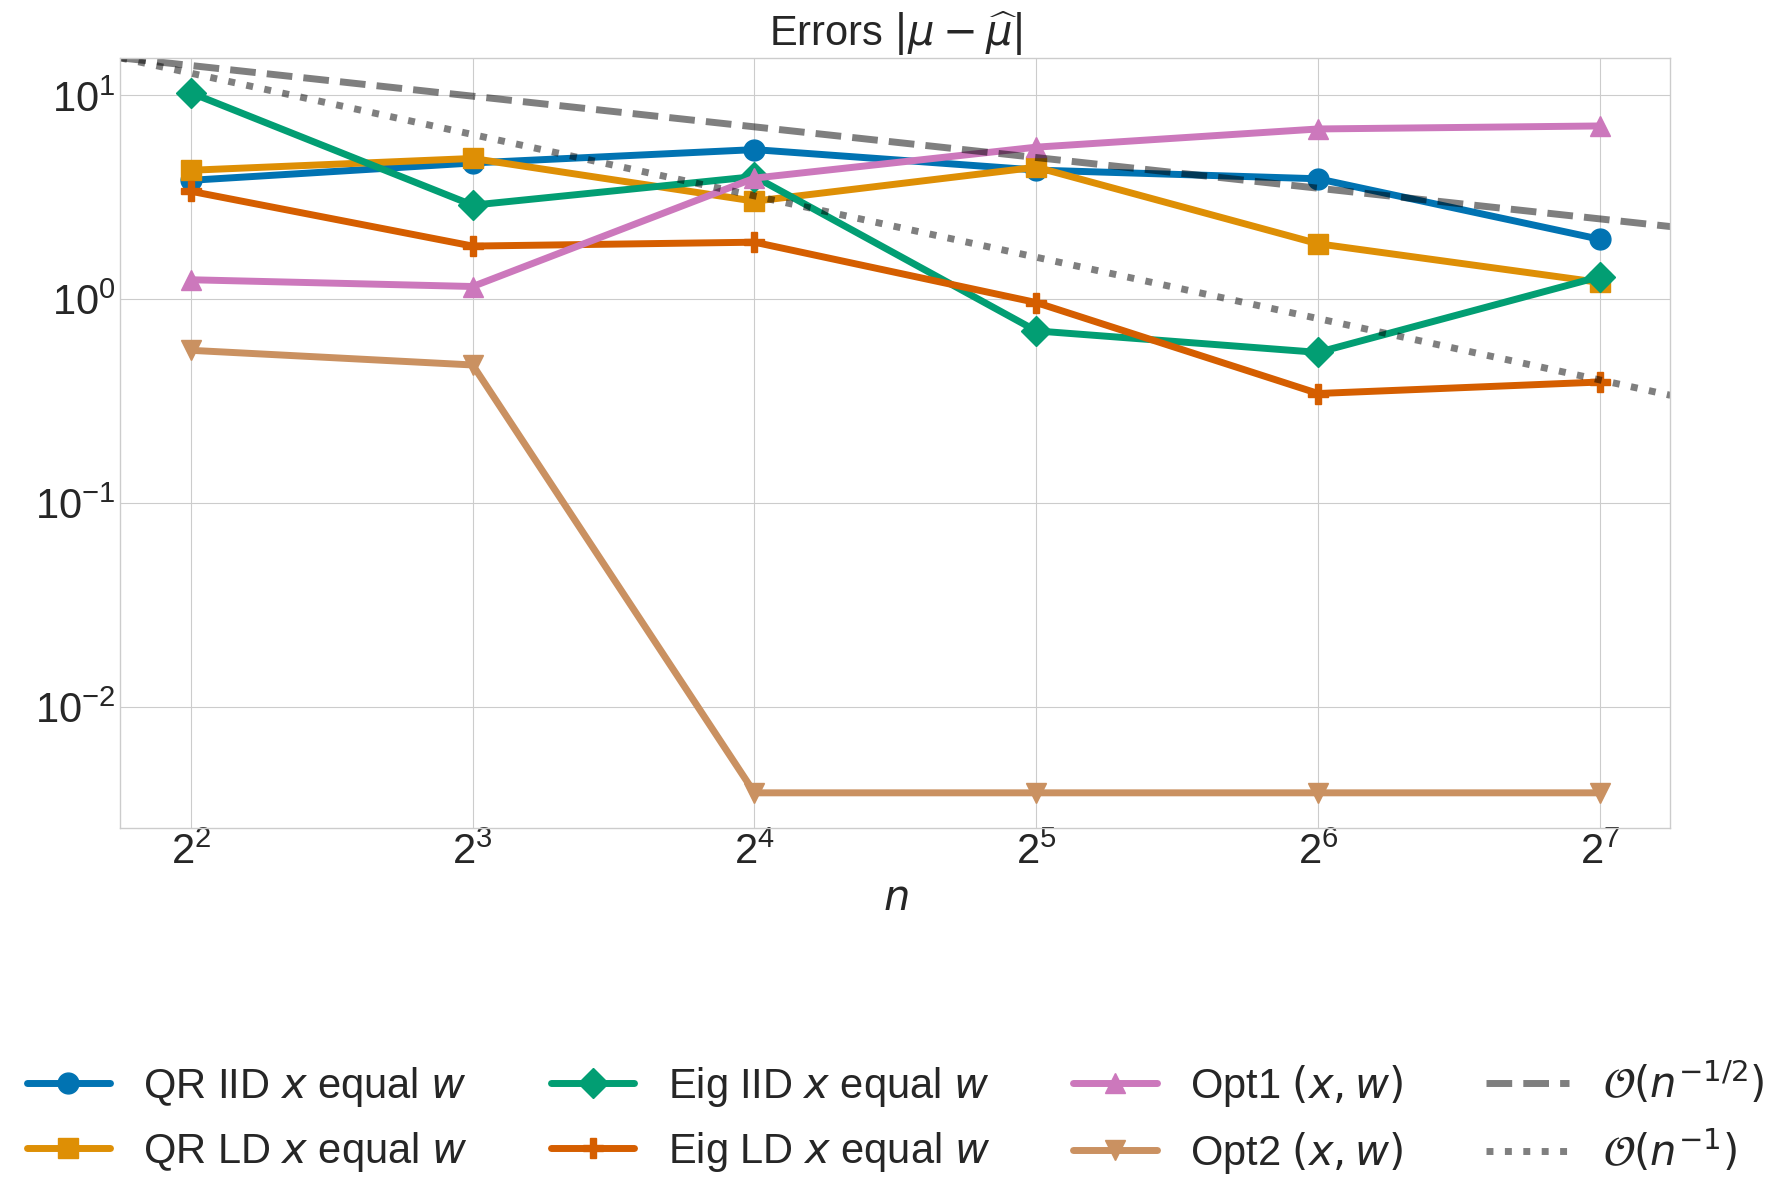

In [10]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,errors[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [11]:
errors_df = pd.DataFrame(errors.median(-1).values.T,columns=[name for (name,func) in genf_funcs])
errors_df['n'] = n
errors_df.set_index('n')
errors_df

,QR IID $x$ equal $w$,QR LD $x$ equal $w$,Eig IID $x$ equal $w$,Eig LD $x$ equal $w$,"Opt1 $(x,w)$","Opt2 $(x,w)$",n
0,3.835397,4.296551,10.304390,3.389859,1.247230,0.562047,4
1,4.666685,4.909600,2.896271,1.824639,1.155608,0.476221,8
2,5.425387,3.029927,4.001100,1.906430,3.932493,0.003790,16
3,4.306644,4.448704,0.699848,0.963768,5.578529,0.003790,32
4,3.902283,1.872770,0.549040,0.344996,6.851059,0.003790,64
5,1.970173,1.209230,1.291834,0.392841,7.088251,0.003790,128
